# Workshop: S2S – Accessing Sub-National Data

**Duration:** 30 minutes  
**Type:** Hands-on exercise  
**Presenter:** Gabe

---

### What you'll learn

1. How to install and set up the Space2Stats Python client
2. How to discover what data is available
3. How to fetch administrative boundaries for any country
4. How to query sub-national statistics and visualize them

### Key takeaway

> *You don't need to download rasters, run zonal stats, or fight with GIS software. Three lines of Python give you sub-national indicators for any country.*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/worldbank/DECAT_Space2Stats/blob/glevin_workshop_prep/workshops/01_accessing_subnational_data.ipynb)

!pip install space2stats-client matplotlib mapclassify

In [ ]:
# Install the client (uncomment if needed)
%pip install space2stats-client

In [2]:
from space2stats_client import Space2StatsClient
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the client — that's it, no auth required
client = Space2StatsClient()

---
## Part 2: Discover What’s Available (5 min)

The API is **self-describing**. You don't need to memorize field names — you can browse topics and fields programmatically.

In [3]:
# What broad topics/datasets are available?
topics = client.get_topics()
topics

Item ID,name,description,source_data
flood_exposure_15cm_1in100,Population Exposed to Floods,Population where flood depth is greater than 1...,Fathom 3.0 High Resolution Global Flood Maps I...
urbanization_ghssmod,Urbanization by population and by area,Urbanization is analyzed using the GHS-SMOD da...,Global Human Settlement Layer (https://human-s...
nighttime_lights,Nighttime Lights,Sum of luminosity values measured by monthly c...,"World Bank - Light Every Night, https://regist..."
climate,Standardized Precipitation Index (SPI),Index for a given timescale measuring drought ...,CHIRPS3
builtarea_ghsl,Built area,Built area (in m2) in 5-year epochs. Source da...,https://human-settlement.emergency.copernicus....
world_pop,Population,Gridded population disaggregated by gender.,"WorldPop gridded population, 2025, Unconstrain..."
cyclones,Tropical Cyclone Frequency,Global tropical cyclone frequency summarized t...,International Best Track Archive for Climate S...
drought,"Drought hazard (SPEI ≤ -1.5, 100-year return p...",Global drought hazard raster: expected number ...,Global Drought Hazard (HDX download): https://...
fires,Fire Density,Fire density (number of fires/km²),NASA MODIS Fire data (https://firms.modaps.eos...
landslide_susceptibility,Landslide Susceptibility Index,Global landslide susceptibility raster (relati...,NASA GPM Landslides Program — Global Landslide...


In [4]:
# What specific fields can I query?
fields = client.get_fields()
print(f"Total available fields: {len(fields)}")
print("\nFirst 20 fields:")
fields[:20]

Total available fields: 106

First 20 fields:


['fires_density_mean',
 'pop',
 'pop_flood',
 'pop_flood_pct',
 'ghs_11_count',
 'ghs_12_count',
 'ghs_13_count',
 'ghs_21_count',
 'ghs_22_count',
 'ghs_23_count',
 'ghs_30_count',
 'ghs_total_count',
 'ghs_11_pop',
 'ghs_12_pop',
 'ghs_13_pop',
 'ghs_21_pop',
 'ghs_22_pop',
 'ghs_23_pop',
 'ghs_30_pop',
 'ghs_total_pop']

In [5]:
# Get detailed metadata about a specific dataset
# (uses the STAC catalog under the hood)
pop_props = client.get_properties("world_pop")
pop_props.head(10)

,name,description,type
0,hex_id,H3 index at resolution 6,string
1,sum_f_00_2025,"Total population female, ages 0 to 1, 2025",float64
2,sum_f_01_2025,"Total population female, ages 1 to 10, 2025",float64
3,sum_f_05_2025,"Total population female, ages 5 to 10, 2025",float64
4,sum_f_10_2025,"Total population female, ages 10 to 15, 2025",float64
5,sum_f_15_2025,"Total population female, ages 15 to 20, 2025",float64
6,sum_f_20_2025,"Total population female, ages 20 to 25, 2025",float64
7,sum_f_25_2025,"Total population female, ages 25 to 30, 2025",float64
8,sum_f_30_2025,"Total population female, ages 30 to 35, 2025",float64
9,sum_f_35_2025,"Total population female, ages 35 to 40, 2025",float64


### 💬 Discussion point

The STAC (SpatioTemporal Asset Catalog) metadata means every field has documented:
- **Source** (e.g., WorldPop, VIIRS, GHSL)
- **Units** and methodology
- **Temporal coverage**

This makes the data traceable and reproducible.

---
## Part 3: Fetch an Area of Interest (5 min)

The client has a built-in helper to fetch official World Bank administrative boundaries.

Number of districts: 30


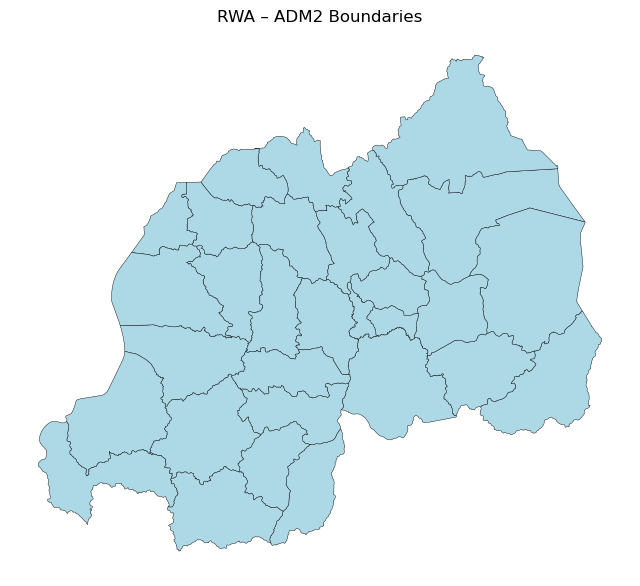

In [6]:
# Fetch ADM2 (district-level) boundaries for Rwanda
ISO3 = "RWA"
ADM = "ADM2"

boundaries = client.fetch_admin_boundaries(ISO3, ADM)
print(f"Number of districts: {len(boundaries)}")
boundaries.plot(figsize=(8, 8), edgecolor="black", linewidth=0.3, color="lightblue")
plt.title(f"{ISO3} – {ADM} Boundaries")
plt.axis("off")
plt.show()

In [7]:
# What does the boundary data look like?
boundaries.head()

,FID,ISO_A3,ISO_A2,WB_A3,WB_REGION,WB_STATUS,NAM_0,NAM_1,ADM1CD_c,GEOM_SRCE,NAM_2,ADM2CD_c,GlobalID,Shape__Area,Shape__Length,geometry
0,8834,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,Bugesera,RWA001001,2dff86e1-6f8f-4537-b099-881600daa753,0.104415,1.682798,"POLYGON ((30.101 -2.42411, 30.09686 -2.42304, ..."
1,8835,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,Gatsibo,RWA001002,88559a06-bef7-4ff4-a176-f34a8663567b,0.128731,2.190899,"POLYGON ((30.7401 -1.45849, 30.74105 -1.47952,..."
2,8836,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,Kayonza,RWA001003,5d736e06-fcf3-435e-b2ed-2b249be630c7,0.157032,1.834130,"POLYGON ((30.41977 -1.84642, 30.42126 -1.84434..."
3,8837,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,Kirehe,RWA001004,0079747c-2f3c-4b03-8f7d-6109d3a08a81,0.096008,1.711863,"POLYGON ((30.5448 -2.41358, 30.53877 -2.41036,..."
4,8838,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,Ngoma,RWA001005,5df66628-0bfc-4b5d-adc0-e38fefc7913b,0.070554,1.415620,"POLYGON ((30.46021 -2.31926, 30.45802 -2.31808..."


### Spatial join methods

When querying, you choose how hexagons relate to your boundary:

| Method | Meaning | When to use |
|--------|---------|-------------|
| `centroid` | Only hexagons whose center falls inside the boundary | Most common — clean, no double-counting |
| `within` | Only hexagons fully contained in the boundary | Conservative estimate |
| `touches` | Any hexagon that overlaps the boundary at all | Inclusive — captures edges |

---
## Part 4: Query Sub-National Data (10 min)

### 4a. Hex-level data with `get_summary()`

This returns one row per hexagon, giving you the finest spatial detail.

In [8]:
# Pick some population fields
pop_fields = ["sum_pop_2025", "sum_f_2025", "sum_m_2025"]

# Query hex-level data for all of Rwanda
hex_data = client.get_summary(
    gdf=boundaries,
    spatial_join_method="centroid",
    fields=pop_fields,
    geometry="polygon"  # include hex geometries for mapping
)

print(f"Rows returned: {len(hex_data)}")
hex_data.head()

Fetching data for boundary 1 of 30...
Fetching data for boundary 2 of 30...
Fetching data for boundary 3 of 30...
Fetching data for boundary 4 of 30...
Fetching data for boundary 5 of 30...
Fetching data for boundary 6 of 30...
Fetching data for boundary 7 of 30...
Fetching data for boundary 8 of 30...
Fetching data for boundary 9 of 30...
Fetching data for boundary 10 of 30...
Fetching data for boundary 11 of 30...
Fetching data for boundary 12 of 30...
Fetching data for boundary 13 of 30...
Fetching data for boundary 14 of 30...
Fetching data for boundary 15 of 30...
Fetching data for boundary 16 of 30...
Fetching data for boundary 17 of 30...
Fetching data for boundary 18 of 30...
Fetching data for boundary 19 of 30...
Fetching data for boundary 20 of 30...
Fetching data for boundary 21 of 30...
Fetching data for boundary 22 of 30...
Fetching data for boundary 23 of 30...
Fetching data for boundary 24 of 30...
Fetching data for boundary 25 of 30...
Fetching data for boundary 26 of 3

,FID,ISO_A3,ISO_A2,WB_A3,WB_REGION,WB_STATUS,NAM_0,NAM_1,ADM1CD_c,GEOM_SRCE,...,GlobalID,Shape__Area,Shape__Length,index_gdf,index_h3,hex_id,geometry,sum_pop_2025,sum_f_2025,sum_m_2025
0,8834,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,...,2dff86e1-6f8f-4537-b099-881600daa753,0.104415,1.682798,0,0,866ad8007ffffff,"{""type"":""Polygon"",""coordinates"":[[[30.19357581...",14581.022461,7114.179713,7466.631106
1,8834,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,...,2dff86e1-6f8f-4537-b099-881600daa753,0.104415,1.682798,0,1,866ad800fffffff,"{""type"":""Polygon"",""coordinates"":[[[30.25174241...",19533.810547,9881.850052,9651.213832
2,8834,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,...,2dff86e1-6f8f-4537-b099-881600daa753,0.104415,1.682798,0,2,866ad8017ffffff,"{""type"":""Polygon"",""coordinates"":[[[30.14433671...",36609.984375,17548.364980,19061.521942
3,8834,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,...,2dff86e1-6f8f-4537-b099-881600daa753,0.104415,1.682798,0,3,866ad801fffffff,"{""type"":""Polygon"",""coordinates"":[[[30.20250970...",28590.443359,14009.044991,14580.863003
4,8834,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,...,2dff86e1-6f8f-4537-b099-881600daa753,0.104415,1.682798,0,4,866ad8027ffffff,"{""type"":""Polygon"",""coordinates"":[[[30.18464629...",29742.515625,15039.735531,14701.835255


### 4b. Interactive map

Explore the hex-level data interactively. Hover to see population values, zoom and pan to explore.

In [38]:
# Fill nulls as zero for display
for col in ["sum_pop_2025", "sum_f_2025", "sum_m_2025"]:
    hex_gdf[col] = hex_gdf[col].fillna(0)

# Pre-bin into categorical column so legend labels are clean
import pandas as pd
hex_gdf["pop_class"] = pd.cut(
    hex_gdf["sum_pop_2025"],
    bins=[0, 5000, 15000, 30000, 60000, 100000, 200000, float("inf")],
    labels=["< 5K", "5K - 15K", "15K - 30K", "30K - 60K", "60K - 100K", "100K - 200K", "> 200K"],
)

# Drop hexagons with zero population so they render as transparent
hex_nonzero = hex_gdf[hex_gdf["sum_pop_2025"] > 0].copy()

m = hex_nonzero.explore(
    column="pop_class",
    cmap="YlOrRd",
    categorical=True,
    legend=True,
    tiles="cartodbpositron",
    tooltip=["hex_id", "sum_pop_2025", "sum_f_2025", "sum_m_2025"],
    tooltip_kwds={"aliases": ["Hex ID", "Population", "Female", "Male"]},
    style_kwds={"weight": 0.5, "fillOpacity": 0.7},
    legend_kwds={"caption": "Population (2025)"},
    name="Population",
)

# Overlay admin boundaries
boundaries.boundary.explore(
    m=m,
    color="black",
    style_kwds={"weight": .3, "fillOpacity": 0},
    name="ADM2 Boundaries",
)

import folium
folium.LayerControl().add_to(m)
m

# Fill nulls as zero for display
from shapely import from_geojson
import pandas as pd

if isinstance(hex_data["geometry"].iloc[0], str):
    hex_data["geometry"] = hex_data["geometry"].apply(lambda g: from_geojson(g))
hex_gdf = gpd.GeoDataFrame(hex_data, geometry="geometry", crs="EPSG:4326")

for col in ["sum_pop_2025", "sum_f_2025", "sum_m_2025"]:
    hex_gdf[col] = hex_gdf[col].fillna(0)

# Pre-bin into categorical column so legend labels are clean
POP_LABELS = ["< 5K", "5K - 15K", "15K - 30K", "30K - 60K", "60K - 100K", "100K - 200K", "> 200K"]
hex_gdf["pop_class"] = pd.cut(
    hex_gdf["sum_pop_2025"],
    bins=[0, 5000, 15000, 30000, 60000, 100000, 200000, float("inf")],
    labels=POP_LABELS,
)

# Drop hexagons with zero population so they render as transparent
hex_nonzero = hex_gdf[hex_gdf["sum_pop_2025"] > 0].copy()

m = hex_nonzero.explore(
    column="pop_class",
    cmap="YlOrRd",
    categorical=True,
    legend=True,
    tiles="cartodbpositron",
    tooltip=["hex_id", "sum_pop_2025", "sum_f_2025", "sum_m_2025"],
    tooltip_kwds={"aliases": ["Hex ID", "Population", "Female", "Male"]},
    style_kwds={"weight": 0.5, "fillOpacity": 0.7},
    legend_kwds={"caption": "Population (2025)"},
    name="Population",
)

# Overlay admin boundaries
boundaries.boundary.explore(
    m=m,
    color="black",
    style_kwds={"weight": 2, "fillOpacity": 0},
    name="ADM2 Boundaries",
)

import folium
folium.LayerControl().add_to(m)
m

### 4c. Pre-computed ADM2 summaries

For common datasets, we also have pre-computed ADM2 summaries available through the [World Bank Development Data Hub (DDH)](https://datacatalog.worldbank.org/).

In [36]:
# What pre-computed ADM2 datasets are available?
client.get_adm2_dataset_info()

,dataset,resource_id,description,url
0,urbanization,DR0095357,Urban and rural settlement data - GHS settleme...,https://datacatalogapi.worldbank.org/ddhxext/v...
1,nighttimelights,DR0095356,Nighttime lights intensity data - satellite-de...,https://datacatalogapi.worldbank.org/ddhxext/v...
2,population,DR0095354,Population statistics - demographic data,https://datacatalogapi.worldbank.org/ddhxext/v...
3,flood_exposure,DR0095355,Flood exposure risk data - flood hazard and ex...,https://datacatalogapi.worldbank.org/ddhxext/v...


In [37]:
# Fetch pre-computed nighttime lights summaries for Rwanda
ntl_adm2 = client.get_adm2_summaries("nighttimelights", iso3_filter="RWA")
ntl_adm2.head()

Fetching nighttimelights data from World Bank DDH API...
Filtering by ISO3: RWA
Retrieved 30 records (total available: 30)


,ADM2CD_c,sum_viirs_ntl_2012,sum_viirs_ntl_2013,sum_viirs_ntl_2014,sum_viirs_ntl_2015,sum_viirs_ntl_2016,sum_viirs_ntl_2017,sum_viirs_ntl_2018,sum_viirs_ntl_2019,sum_viirs_ntl_2020,sum_viirs_ntl_2021,sum_viirs_ntl_2022,sum_viirs_ntl_2023,sum_viirs_ntl_2024,ISO3
0,RWA001001,2769.4715700959664,2355.708742543226,3129.414188431405,2945.1127969184213,3075.268948210417,3874.354002708908,3437.4937151172217,2307.047736414644,3330.9789208652205,4375.175978035811,5068.335215083616,6253.062933373636,3956.772915798831,RWA
1,RWA001002,4274.191060308106,16989.436065674312,4266.976999857109,5806.561231870948,4346.222493199778,4453.71857721263,4030.667026667618,2531.4330637848593,3286.87168610463,3766.1769533311654,4299.516442256796,5393.385719327768,2119.051180622187,RWA
2,RWA001003,5153.984482782207,5276.980465946967,8790.774240297333,10778.9733298708,5604.519919874975,5083.776159224298,4266.250024503474,2682.43712948026,3772.8209823695597,4563.458394819019,4615.204806184705,6370.07718287838,2559.387673922603,RWA
3,RWA001004,2339.3494688694045,2086.711398002539,3137.513378476488,2934.829609507987,2571.6602907507995,2851.3274488641355,2614.449509061019,1809.0286802758358,2355.8826448768405,2918.5300695255937,2940.7323192690437,3843.0661290634102,1586.4672704714278,RWA
4,RWA001005,1658.7219321958182,1543.309703634223,2445.986366263006,2184.8886672885083,1794.8662938325429,2327.817478993826,2082.819770711048,1148.1522836212503,1704.5204387285694,1984.4911514640332,2240.31652484347,2900.7319667769143,1209.79655170047,RWA


---
## Part 5: Your Turn! (5 min)

### Challenge

Pick a **different country and dataset** and create a map. Some ideas:

| Country | ISO3 | Interesting fields |
|---------|------|--------------------|
| Colombia | COL | `sum_pop_2025`, nighttime lights |
| Bangladesh | BGD | `pop_flood` (flood exposure) |
| Nigeria | NGA | `sum_f_2025` vs `sum_m_2025` |
| Sri Lanka | LKA | `sum_viirs_ntl_2024` (nighttime lights) |

**Steps:**
1. Fetch boundaries: `client.fetch_admin_boundaries("YOUR_ISO3", "ADM2")`
2. Pick fields: browse `client.get_fields()` or `client.get_topics()`
3. Query: `client.get_aggregate(...)` or `client.get_summary(...)`
4. Visualize!

In [ ]:
# Your code here!



---
## Recap

| What we did | Method |
|---|---|
| Discovered available data | `get_topics()`, `get_fields()`, `get_properties()` |
| Fetched admin boundaries | `fetch_admin_boundaries(iso3, adm)` |
| Got hex-level detail | `get_summary(gdf, spatial_join_method, fields)` |
| Got district-level totals | `get_aggregate(gdf, spatial_join_method, fields, aggregation_type)` |
| Used pre-computed summaries | `get_adm2_summaries(dataset, iso3_filter)` |

